# CICIDS2017 Cybersecurity EDA — Snippets Version

This notebook repeats the initial cybersecurity EDA workflow using the reusable `snippets_v2.py` toolkit.

The purpose is to demonstrate how repetitive Data Analyst tasks can be simplified with reusable functions while keeping the underlying Pandas workflow understandable.

## 1. Import Libraries and Snippets

Because `snippets_v2.py` is stored in the project root while this notebook is inside `notebooks/`, the project root is added to the Python path.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Allow the notebook to import snippets_v2.py from the project root
sys.path.append(str(Path.cwd().parent))

from snippets_v2 import *

## 2. Load Dataset

In [2]:
df = load_csv('../data/CICIDS2017_sample.csv')
df.head()

,2Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,4,2,0,37,0,31,6,18.500000,17.677670,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,142377,46,62,1325,105855,570,0,28.804348,111.407285,4344,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,118873,23,28,1169,45025,570,0,50.826087,156.137367,2896,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,143577,43,55,1301,107289,570,0,30.255814,115.178969,4344,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,143745,49,59,1331,110185,570,0,27.163265,108.067176,4344,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## 3. Quick Dataset Inspection

`quick_eda()` provides a fast overview without automatically modifying or deleting data.

In [3]:
quick_eda(df)

QUICK EDA

Shape: (56661, 78)

Data types:
int64      53
float64    24
object      1
Name: count, dtype: int64

Missing values:


,missing_count,missing_pct
Flow Bytes/s,54,0.1
2Flow Duration,0,0.0
Total Backward Packets,0,0.0
Total Length of Fwd Packets,0,0.0
Total Length of Bwd Packets,0,0.0
Total Fwd Packets,0,0.0
Fwd Packet Length Max,0,0.0
Fwd Packet Length Min,0,0.0
Fwd Packet Length Std,0,0.0
Fwd Packet Length Mean,0,0.0



Duplicate rows: 12598

Numeric columns:
['2Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag C

,2Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,4,2,0,37,0,31,6,18.500000,17.677670,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,142377,46,62,1325,105855,570,0,28.804348,111.407285,4344,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,118873,23,28,1169,45025,570,0,50.826087,156.137367,2896,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,143577,43,55,1301,107289,570,0,30.255814,115.178969,4344,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,143745,49,59,1331,110185,570,0,27.163265,108.067176,4344,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## 4. Data Quality

Check missing values and duplicate rows before continuing with the analysis.

In [4]:
missing_summary(df).head(15)

,missing_count,missing_pct
Flow Bytes/s,54,0.1
2Flow Duration,0,0.0
Total Backward Packets,0,0.0
Total Length of Fwd Packets,0,0.0
Total Length of Bwd Packets,0,0.0
Total Fwd Packets,0,0.0
Fwd Packet Length Max,0,0.0
Fwd Packet Length Min,0,0.0
Fwd Packet Length Std,0,0.0
Fwd Packet Length Mean,0,0.0


In [5]:
duplicates_summary(df)

duplicate_count    12598.00
duplicate_pct         22.23
dtype: float64

## 5. Column Overview

In [6]:
print('Numeric columns:')
print(numeric_cols(df))

print('\nCategorical columns:')
print(categorical_cols(df))

Numeric columns:
['2Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count',

## 6. Traffic Distribution

Analyze the distribution of traffic labels.

In [7]:
freq(df, 'Label')

Label
BENIGN          22731
DoS             19035
PortScan         7946
BruteForce       2767
WebAttack        2180
Bot              1966
Infiltration       36
Name: count, dtype: int64

In [8]:
freq(df, 'Label', normalize=True)

Label
BENIGN          40.12
DoS             33.59
PortScan        14.02
BruteForce       4.88
WebAttack        3.85
Bot              3.47
Infiltration     0.06
Name: proportion, dtype: float64

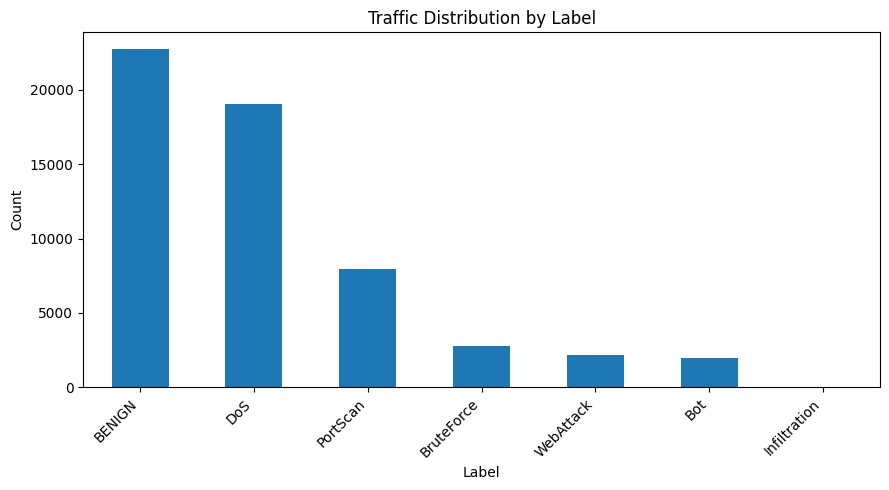

In [9]:
plot_count(df, 'Label', title='Traffic Distribution by Label')

## 7. Attack Traffic

Create a subset containing only non-benign traffic.

In [10]:
df_attack = df[df['Label'] != 'BENIGN'].copy()

print('Attack traffic shape:', df_attack.shape)
freq(df_attack, 'Label')

Attack traffic shape: (33930, 78)


Label
DoS             19035
PortScan         7946
BruteForce       2767
WebAttack        2180
Bot              1966
Infiltration       36
Name: count, dtype: int64

## 8. Grouped Statistics

Compare network-flow characteristics between attack categories.

In [11]:
group_stats(
    df_attack,
    'Label',
    'Total Fwd Packets'
)

,count,mean,median,min,max
Label,,,,,
Infiltration,36,830.222222,26.0,2,5523
WebAttack,2180,10.945413,3.0,1,212
BruteForce,2767,7.847488,2.0,1,31
DoS,19035,5.064723,5.0,1,19
Bot,1966,3.193795,3.0,1,39
PortScan,7946,1.016486,1.0,1,6


In [12]:
group_stats(
    df_attack,
    'Label',
    'Flow Bytes/s'
)

,count,mean,median,min,max
Label,,,,,
Bot,1966,inf,5047.484518,0.000000,inf
PortScan,7946,inf,139534.883700,0.000000,inf
BruteForce,2767,4.658562e+05,340.398579,0.000000,1.400000e+07
DoS,18984,2.597306e+05,121.592139,0.000000,9.920000e+08
Infiltration,36,2.018822e+04,173.351370,1.273469,6.000000e+05
WebAttack,2180,1.579135e+02,0.000000,0.000000,7.589090e+03


## 9. Outlier Analysis

Use the IQR method to identify unusually high values in `Total Fwd Packets`.

In [13]:
outlier_result = outlier_iqr(df_attack, 'Total Fwd Packets')

for key, value in outlier_result.items():
    if key != 'outlier_rows':
        print(f'{key}: {value}')

Q1: 1.0
Q3: 6.0
IQR: 5.0
lower_bound: -6.5
upper_bound: 13.5
outlier_count: 839
outlier_pct: 2.47


In [14]:
outlier_result['outlier_rows'].head()

,2Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
17617,160712,27,53,115100,434,13140,0,4262.962963,3320.650417,128,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Bot
17642,90712,21,28,64938,284,7300,0,3092.285714,2399.381361,128,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Bot
17666,95744,38,78,190959,584,18980,0,5025.236842,5396.903914,128,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Bot
17670,78413,21,34,57592,320,5840,0,2742.476190,1726.635214,128,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Bot
17676,85043,21,30,64935,296,5840,0,3092.142857,1984.699279,128,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Bot


## 10. Correlation Analysis

Identify strongly correlated numeric features.

In [15]:
corr_pairs(df, min_abs=0.7).head(15)

,feature_1,feature_2,abs_corr
119,Total Fwd Packets,Subflow Fwd Packets,1.000000
497,Fwd Packet Length Mean,Avg Fwd Segment Size,1.000000
251,Total Length of Fwd Packets,Subflow Fwd Bytes,1.000000
187,Total Backward Packets,Subflow Bwd Packets,1.000000
1620,Fwd URG Flags,CWE Flag Count,1.000000
1663,Fwd Header Length,Fwd Header Length.1,1.000000
1577,Fwd PSH Flags,SYN Flag Count,1.000000
1999,RST Flag Count,ECE Flag Count,1.000000
732,Bwd Packet Length Mean,Avg Bwd Segment Size,1.000000
317,Total Length of Bwd Packets,Subflow Bwd Bytes,1.000000


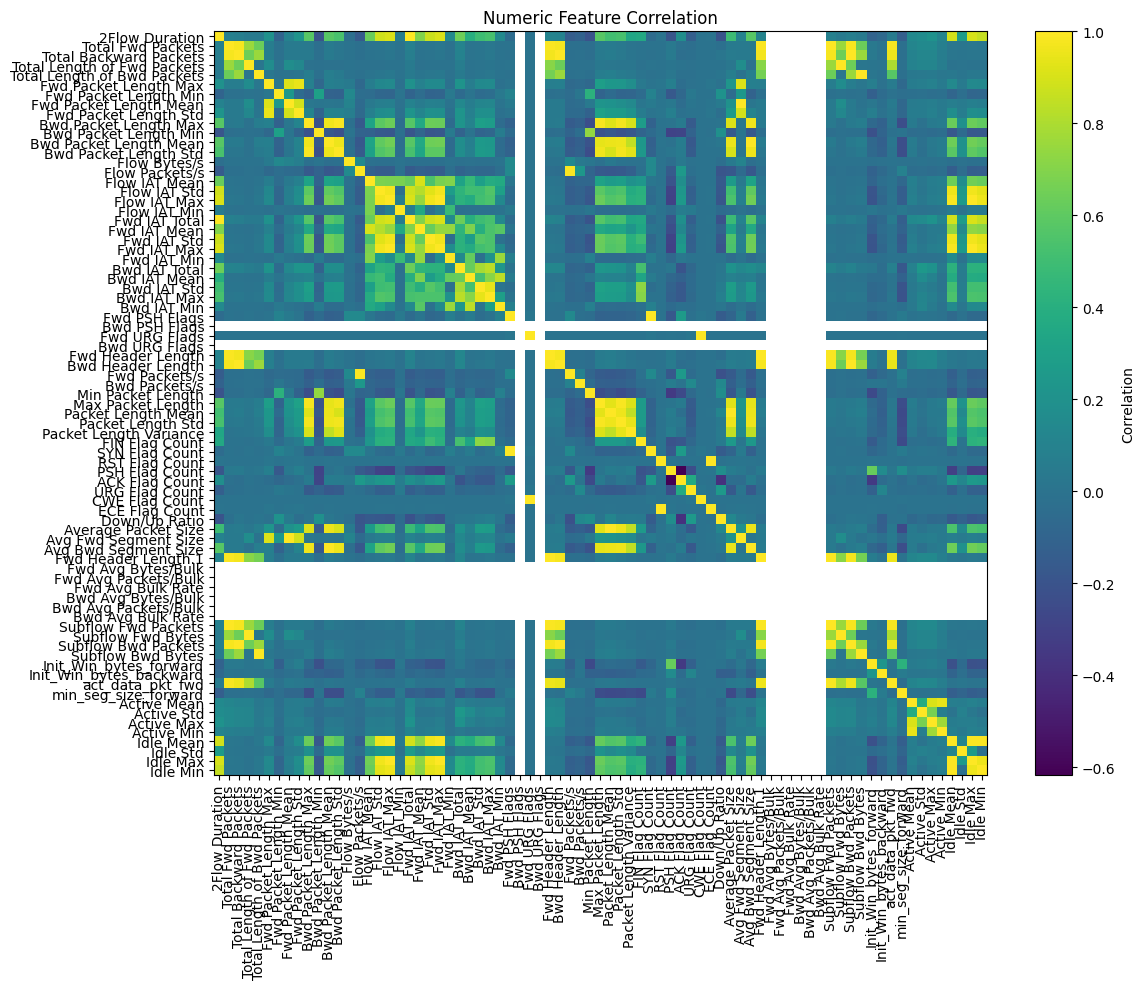

In [16]:
plot_corr_heatmap(df, figsize=(12, 10), title='Numeric Feature Correlation')

## 11. Distribution and Relationship Analysis

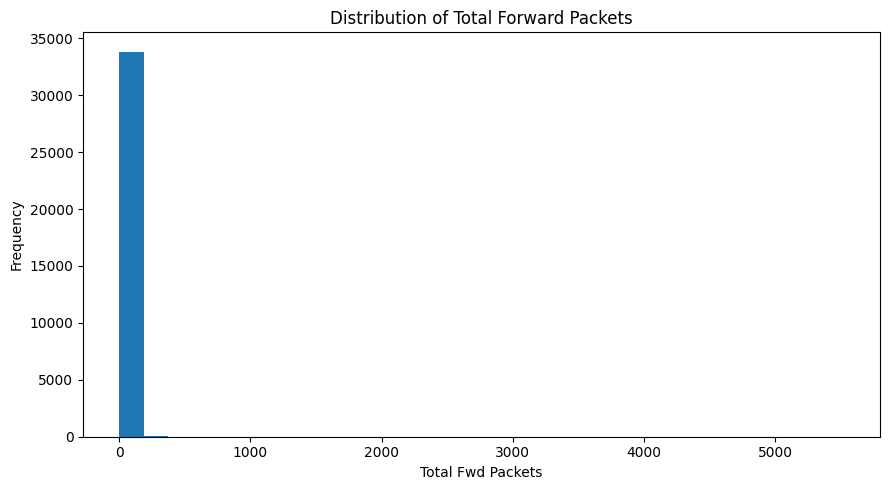

In [17]:
plot_hist(df_attack, 'Total Fwd Packets', title='Distribution of Total Forward Packets')

<Figure size 900x500 with 0 Axes>

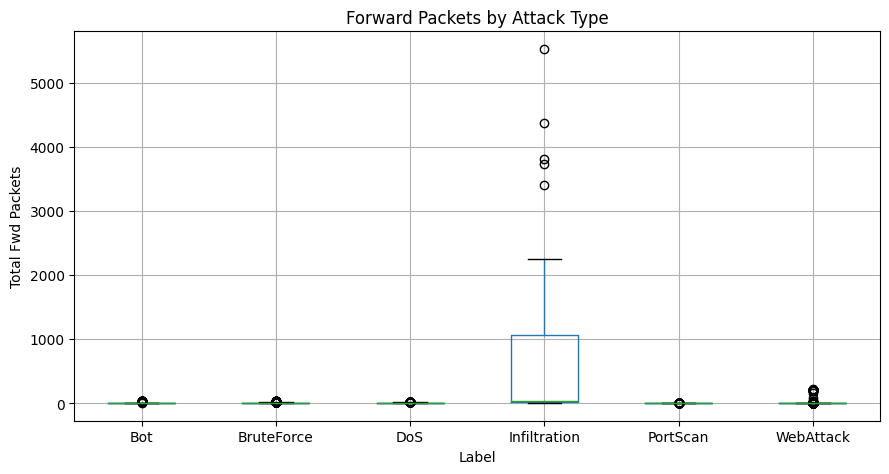

In [18]:
plot_box(df_attack, 'Total Fwd Packets', by='Label', title='Forward Packets by Attack Type')

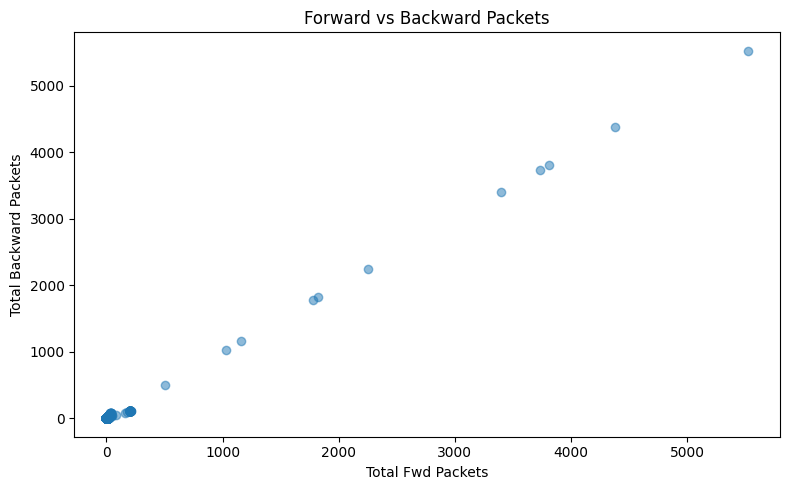

In [19]:
plot_scatter(
    df_attack,
    'Total Fwd Packets',
    'Total Backward Packets',
    title='Forward vs Backward Packets'
)

## 12. Key Findings

- The dataset contains both benign and attack traffic represented by the `Label` column.
- Attack categories have different distributions and network-flow characteristics.
- IQR analysis can be used to identify unusually high packet counts for further investigation.
- Correlation analysis helps identify pairs of numerical features with strong relationships.
- Visualization provides a faster way to communicate distributions, differences between categories, and feature relationships.

The conclusions above should be interpreted from the computed results in this notebook rather than as evidence that one attack type is inherently more dangerous than another.